<a href="https://colab.research.google.com/github/saloni-081205/india-air-quality-analysis/blob/main/PDS_OEP_(India_Air_Quality_Index).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATASET DESCRIPTION**
**Dataset link :** https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india

**Context** :
Air is what keeps humans alive. Monitoring it and understanding its quality is of immense importance to our well-being.

**Content** :
The dataset contains air quality data and AQI (Air Quality Index) at hourly and daily level of various stations across multiple cities in India from (2015 - 2020)

**Cities:** Ahmedabad, Aizawl, Amaravati, Amritsar, Bengaluru, Bhopal, Brajrajnagar, Chandigarh, Chennai, Coimbatore, Delhi, Ernakulam, Gurugram, Guwahati, Hyderabad, Jaipur, Jorapokhar, Kochi, Kolkata, Lucknow, Mumbai, Patna, Shillong, Talcher, Thiruvananthapuram, Visakhapatnam

The data has been made publicly available by the Central Pollution Control Board: https://cpcb.nic.in/ which is the official portal of Government of India. They also have a real-time monitoring app: https://app.cpcbccr.com/AQI_India/





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## **PHASE 1: LOAD & UNDERSTAND DATA**
**PURPOSE**:
Before doing anything, we must know what data looks like — columns, missing values, data types.


In [ ]:
# Load dataset
df = pd.read_csv("city_day.csv")

print("="*60)
print("DATA UNDERSTANDING REPORT")
print("="*60)

print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

print(f"\nColumn Names:")
print(df.columns.tolist())

print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nData Types:")
print(df.dtypes.value_counts())

print(f"\nMissing Values Summary:")
missing = df.isnull().sum()
missing_pct = (missing/len(df))*100
missing_report = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print(missing_report)

DATA UNDERSTANDING REPORT

Dataset Shape: 29531 rows × 16 columns

Column Names:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

First 5 rows:
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


**OBSERVATIONS & INSIGHTS FROM PHASE 1 (DATA UNDERSTANDING):**

1. Dataset contains 29,531 rows and 16 columns representing daily air quality measurements across multiple Indian cities from 2015-2020.

2. Key columns include City (location), Date (temporal reference), 11 pollutant concentrations (PM2.5, PM10, NO2, CO, SO2, O3, etc.), AQI (Air Quality Index), and AQI_Bucket (categorical rating).

3. Data Types: 13 columns are float64 (numeric pollutants + AQI), 3 columns are object (City, Date, AQI_Bucket) — requires conversion for analysis.

4. Missing Values are significant:
   - Xylene has highest missing (61.3% / 18,109 missing)
   - PM10 (37.7%), NH3 (34.9%), Toluene (27.2%) show substantial gaps
   - AQI and AQI_Bucket both missing 4,681 rows (15.85%)
   - Even key pollutants like PM2.5 missing 4,598 rows (15.6%)

5. Critical Finding: AQI values are missing for ~16% of records, meaning these days cannot be used for analysis without imputation.

6. Action Required: Missing value treatment is essential before any statistical analysis or modeling — median imputation recommended due to expected outliers in pollution data.

7. Data Type Conversion Needed: Date → datetime, City → category, AQI_Bucket → category, all pollutant columns → numeric (already float64 but need missing handling).

8. This dataset is ideal for time-series analysis, city comparison, and pollution prediction, but requires systematic cleaning before EDA and modeling.




## **PHASE 2: DATA TYPE CONVERSION**
# **2.1 Convert Data Types**

**PURPOSE**:
Correct data types are essential for mathematical operations, filtering, and grouping.


In [ ]:
print("="*60)
print("DATA TYPE CONVERSION")
print("="*60)

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])
print("Converted 'Date' to datetime")

# Convert City to category (optimizes memory and grouping)
df['City'] = df['City'].astype('category')
print("Converted 'City' to category")

# Convert AQI_Bucket to category
df['AQI_Bucket'] = df['AQI_Bucket'].astype('category')
print("Converted 'AQI_Bucket' to category")

# List of numeric pollutant columns
numeric_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

# Convert each to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Converted {len(numeric_cols)} columns to numeric")

print("\nUpdated Data Types:")
print(df.dtypes.value_counts())

DATA TYPE CONVERSION
Converted 'Date' to datetime
Converted 'City' to category
Converted 'AQI_Bucket' to category
Converted 13 columns to numeric

Updated Data Types:
float64           13
category           1
datetime64[ns]     1
category           1
Name: count, dtype: int64


**OBSERVATIONS & INSIGHTS FROM PHASE 2.1 (DATA TYPE CONVERSION):**

1. Date column successfully converted from object to datetime64[ns] — now enables time-based operations like extracting year, month, season, and day-of-week for temporal pattern analysis.

2. City column converted from object to category — reduces memory usage (important for 29,531 rows with repeated city names) and enables faster groupby operations for city-wise comparisons.

3. AQI_Bucket column converted from object to category — optimizes storage for the 6 distinct air quality categories (Good, Satisfactory, Moderate, Poor, Very Poor, Severe) and enables efficient frequency counting.

4. All 13 pollutant columns (PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene, Xylene, AQI) confirmed as float64 — ready for mathematical operations like mean, median, correlation, and regression.

5. Post-conversion data types: 13 float64 (pollutants), 2 category (City, AQI_Bucket), 1 datetime64[ns] (Date) — clean and analysis-ready structure.





# **2.2 Handle Missing Values**
**PURPOSE:** Missing values can skew statistics and break models. We need a smart strategy to fill them.

In [ ]:
print("="*60)
print("MISSING VALUE HANDLING")
print("="*60)

# Check missing before handling
missing_before = df[numeric_cols].isnull().sum().sum()
print(f"Total missing values before: {missing_before}")

# Fill missing values with column median (robust against outliers)
#
for col in numeric_cols:
   #  df[col] = df.groupby('City')[col].transform(lambda x: x.fillna(x.median()))   (still missing values left)
    df[col] = df[col].fillna(df[col].median())

# Fill AQI_Bucket missing values with mode
df['AQI_Bucket'] = df['AQI_Bucket'].fillna(df['AQI_Bucket'].mode()[0])

# Verify
missing_after = df[numeric_cols].isnull().sum().sum()
print(f"Total missing values after: {missing_after}")
print(f"Handled {missing_before - missing_after} missing values")

df.info()

MISSING VALUE HANDLING
Total missing values before: 83807
Total missing values after: 0
Handled 83807 missing values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        29531 non-null  category      
 1   Date        29531 non-null  datetime64[ns]
 2   PM2.5       29531 non-null  float64       
 3   PM10        29531 non-null  float64       
 4   NO          29531 non-null  float64       
 5   NO2         29531 non-null  float64       
 6   NOx         29531 non-null  float64       
 7   NH3         29531 non-null  float64       
 8   CO          29531 non-null  float64       
 9   SO2         29531 non-null  float64       
 10  O3          29531 non-null  float64       
 11  Benzene     29531 non-null  float64       
 12  Toluene     29531 non-null  float64       
 13  Xylene      29531 non-null  float64       
 14  A

**OBSERVATIONS FROM MISSING VALUE HANDLING:**

- Total missing: 83,807 cells (17.7% of dataset)
- Strategy used: Column-wise median imputation
- Why median? Pollution data has extreme outliers (AQI >400) — median is robust against outliers
- Result: 0 missing values across all 29,531 rows × 16 columns
- Memory: 3.6MB → 3.2MB (optimized due to category dtypes)
- Data preserved: All rows kept (no deletion of incomplete records)
- Status: Dataset is now COMPLETE and READY for EDA

# **2.3 DateTime Feature Extraction**
**PURPOSE:** Extract temporal features to analyze pollution patterns across time.

In [ ]:
print("="*60)
print("DATETIME FEATURE EXTRACTION")
print("="*60)

# Extract basic date components
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()

print("Extracted: Year, Month, Day, DayOfWeek")

# Function to determine season in Indian context
def get_indian_season(month):
    if month in [12, 1, 2]:
        return 'Winter (Dec-Feb)'
    elif month in [3, 4, 5]:
        return 'Summer (Mar-May)'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon (Jun-Sep)'
    else:
        return 'Post-Monsoon (Oct-Nov)'

df['Season'] = df['Month'].apply(get_indian_season)

print("Added Season column (Winter, Summer, Monsoon, Post-Monsoon)")

# Check unique years
years = df['Year'].unique()
print(f"\nData available for years: {years}")

DATETIME FEATURE EXTRACTION
Extracted: Year, Month, Day, DayOfWeek
Added Season column (Winter, Summer, Monsoon, Post-Monsoon)

Data available for years: [2015 2016 2017 2018 2019 2020]


**OBSERVATIONS FROM DATETIME FEATURE EXTRACTION:**

| Extracted Feature | Values | Analytical Use |
|------------------|--------|----------------|
| Year | 2015, 2016, 2017, 2018, 2019, 2020 | Trend analysis, COVID impact study |
| Month | 1 to 12 | Peak pollution month identification |
| DayOfWeek | Monday to Sunday | Weekend vs weekday comparison |
| Season | Winter, Summer, Monsoon, Post-Monsoon | Seasonal pattern analysis |

**Key Insight:** Data includes COVID-19 lockdown period (March-May 2020) — serves as natural experiment showing minimum achievable pollution levels when emissions are restricted.

**Coverage:** 6 complete years → sufficient for statistically significant temporal analysis.

# **2.4 Filter and Subset Data**
**PURPOSE**: Focus on complete years and remove any unreliable data.

In [ ]:
print("="*60)
print("DATA FILTERING")
print("="*60)

# Filter to keep only complete years (2016-2020)
initial_rows = len(df)
df = df[df['Year'].between(2016, 2020)]
print(f"Kept only years 2016-2020: {initial_rows} → {len(df)} rows")

'''
# Remove any rows where AQI is still missing (should be none)
df = df.dropna(subset=['AQI'])
print(f"Removed rows with missing AQI: {len(df)} rows remaining")
'''

# Get top 10 most frequent cities for focused analysis
top_cities = df['City'].value_counts().head(10).index.tolist()
print(f"\nTop 10 cities with most data:")
for i, city in enumerate(top_cities, 1):
    print(f"   {i}. {city}")

DATA FILTERING
Kept only years 2016-2020: 29531 → 26730 rows

Top 10 cities with most data:
   1. Ahmedabad
   2. Bengaluru
   3. Chennai
   4. Hyderabad
   5. Patna
   6. Mumbai
   7. Lucknow
   8. Delhi
   9. Gurugram
   10. Visakhapatnam


**OBSERVATIONS FROM DATA FILTERING:**

| Filtering Action | Before | After | Change |
|-----------------|--------|-------|--------|
| Years kept | 2015-2020 | 2016-2020 | Removed 2015 (partial year) |
| Total rows | 29,531 | 26,730 | -2,801 rows (9.5% removed) |

**Top 10 Cities with Most Data (2016-2020):**

| Rank | City | Why Important |
|------|------|----------------|
| 1 | Ahmedabad | Highest data density, extreme AQI variability (max 2049) |
| 2 | Bengaluru | Southern city benchmark, relatively cleaner |
| 3 | Chennai | Coastal city, moderate pollution |
| 4 | Hyderabad | Tech hub, moderate pollution |
| 5 | Patna | Eastern India, severe pollution episodes |
| 6 | Mumbai | Financial capital, moderate but persistent pollution |
| 7 | Lucknow | North Indian, high pollution |
| 8 | Delhi | National capital, MOST POLLUTED among major cities |
| 9 | Gurugram | NCR region, extreme variability |
| 10 | Visakhapatnam | Coastal industrial city, moderate |

**Key Insights:**
- **Removed 2015** to ensure complete year analysis (2015 had partial data starting Jan 1 only)
- **2,801 rows removed** represents 9.5% of data — acceptable loss for data quality
- **Delhi ranks 8th in data count** but is actually most polluted (AQI 250+) — data quantity ≠ pollution severity
- **Ahmedabad has most data** but also shows extreme AQI (max 2049) — possible data anomaly or severe dust events
- **Geographic coverage** includes North (Delhi, Lucknow), South (Bengaluru, Chennai), East (Patna), West (Ahmedabad, Mumbai) — PAN India representation

**Actionable Insight:** All top 10 cities have sufficient data for city-specific time-series analysis and model training.

## **PHASE 3: DATA AGGREGATION & GROUPING**
# **3.1 GroupBy for City Analysis**

**PURPOSE:**
Compare pollution levels across different Indian cities.


In [ ]:
print("="*60)
print("CITY-WISE AGGREGATION")
print("="*60)

# City-wise statistics
city_stats = df.groupby('City')['AQI'].agg(['mean', 'median', 'min', 'max', 'std']).round(2)
city_stats = city_stats.sort_values('mean', ascending=False)

print("\nPolluted Cities (by average AQI):")
print(city_stats)


CITY-WISE AGGREGATION

Polluted Cities (by average AQI):
                      mean  median   min     max     std
City                                                    
Ahmedabad           358.25   249.0  72.0  2049.0  316.27
Delhi               250.29   241.5  29.0   716.0  124.97
Lucknow             218.56   205.0  39.0   604.0  114.11
Patna               215.51   168.0  53.0   619.0  118.74
Gurugram            212.68   182.0  38.0   891.0  117.87
Talcher             159.42   118.0  13.0   570.0   94.10
Jorapokhar          145.21   118.0  27.0   604.0   71.50
Brajrajnagar        142.54   118.0  22.0   355.0   62.87
Guwahati            139.80   100.0  25.0   956.0  111.99
Kolkata             138.90   101.5  26.0   475.0  100.74
Jaipur              133.40   121.0  43.0   457.0   53.86
Bhopal              132.26   118.0  37.0   312.0   54.99
Amritsar            119.77   107.0  20.0   869.0   73.91
Visakhapatnam       117.42   117.0  23.0   387.0   49.12
Mumbai              112.04   11

**OBSERVATIONS FROM CITY-WISE AGGREGATION:**

**Top 5 Most Polluted Cities (by Mean AQI):**

| Rank | City | Mean AQI | Median AQI | Std Dev | Category | Key Finding |
|------|------|----------|------------|---------|----------|-------------|
| 1 | Ahmedabad | 358.25 | 249.0 | 316.27 | Severe | Extreme variability (max 2049!) |
| 2 | Delhi | 250.29 | 241.5 | 124.97 | Very Poor | Consistently high, moderate variation |
| 3 | Lucknow | 218.56 | 205.0 | 114.11 | Poor | North Indian pollution belt |
| 4 | Patna | 215.51 | 168.0 | 118.74 | Poor | High max (619) but lower median |
| 5 | Gurugram | 212.68 | 182.0 | 117.87 | Poor | NCR region, extreme events (891) |

**Bottom 5 Cleanest Cities (by Mean AQI):**

| Rank | City | Mean AQI | Median AQI | Category | Key Finding |
|------|------|----------|------------|----------|-------------|
| 1 | Aizawl | 36.24 | 24.0 | Good | Only city in "Good" category! |
| 2 | Shillong | 75.54 | 69.5 | Satisfactory | Northeast, forest cover helps |
| 3 | Coimbatore | 77.92 | 77.5 | Satisfactory | Southern city, industrial but clean |
| 4 | Thiruvananthapuram | 78.15 | 69.0 | Satisfactory | Coastal, good dispersion |
| 5 | Bengaluru | 91.43 | 84.0 | Satisfactory | IT hub, relatively clean |

**Critical Statistical Observations:**

| Metric | Value | Insight |
|--------|-------|---------|
| Mean vs Median Gap (Ahmedabad) | 358 vs 249 | Extreme outliers pulling average up |
| Highest Max AQI | 2049 (Ahmedabad) | Possible data error or extreme dust storm |
| Highest Std Dev | 316.27 (Ahmedabad) | Most inconsistent air quality |
| Lowest Std Dev | 19.74 (Ernakulam) | Most consistent, stable pollution |
| Delhi's Consistency | Mean 250, Median 241 | Reliable prediction possible |
| Aizawl's Achievement | Mean 36, Median 24 | Only city meeting WHO standard (AQI <50) |

**Geographic Pattern Analysis:**

| Region | Representative Cities | Average AQI | Insight |
|--------|----------------------|-------------|---------|
| North India | Delhi, Lucknow, Gurugram | ~227 | Most polluted region |
| East India | Patna, Kolkata | ~177 | Moderate-high pollution |
| West India | Ahmedabad, Mumbai | ~235 | Highly variable (Ahmedabad skews) |
| South India | Bengaluru, Chennai, Hyderabad | ~105 | Cleanest metro region |
| Northeast | Aizawl, Shillong, Guwahati | ~84 | Cleanest overall region |

**Key Insights:**

1. **Alarming Finding:** Only 1 city (Aizawl) averages in "Good" category — rest of India breathes unhealthy air daily.

2. **North-South Divide:** Northern cities average 200+ AQI (Poor/Very Poor), Southern cities average ~100 (Moderate) — geography and wind patterns matter.

3. **Ahmedabad Anomaly:** Mean AQI 358 but median 249 suggests extreme events. Max 2049 needs investigation — possible sensor error or severe dust storm.

4. **Delhi is Most Reliably Polluted:** Low standard deviation relative to mean — pollution is consistently bad, not just episodic.

5. **Coastal Advantage:** Mumbai, Chennai, Visakhapatnam show moderate pollution — sea breeze aids dispersion.

6. **Northeast is National Benchmark:** Aizawl (36), Shillong (75) show what India could achieve with forest cover and less industrial activity.

**Policy Recommendation:**
- North India needs emergency measures (winter action plan)
- South India needs preventive measures before it worsens
- Northeast needs preservation of existing clean air
- Ahmedabad requires data quality audit for 2049 AQI reading

# **3.2 Year-wise and Season-wise Analysis**
**PURPOSE:**
Identify temporal patterns in air pollution.

In [ ]:
print("="*60)
print("TEMPORAL AGGREGATION")
print("="*60)

# Year-wise average
yearly_avg = df.groupby('Year')['AQI'].agg(['mean', 'median', 'std']).round(2)
print("\nYear-wise AQI Statistics:")
print(yearly_avg)

# Season-wise average
seasonal_avg = df.groupby('Season')['AQI'].mean().sort_values(ascending=False)
print("\nSeason-wise Average AQI:")
for season, aqi in seasonal_avg.items():
    print(f"   {season}: {aqi:.1f}")

# Month-wise average
# Ensure 'Month' column uses full month names
df['Month_name'] = df['Date'].dt.month_name()
monthly_avg = df.groupby('Month_name')['AQI'].mean()

# To ensure the chronological order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_avg = monthly_avg.reindex(month_order)

print("\nMonth-wise Average AQI:")
# Iterate over the reindexed monthly_avg to print in order
for month_name, aqi_value in monthly_avg.items():
    print(f"   {month_name}: {aqi_value:.1f}")

TEMPORAL AGGREGATION

Year-wise AQI Statistics:
        mean  median     std
Year                        
2016  176.55   118.0  117.49
2017  161.78   118.0  121.03
2018  175.22   118.0  162.66
2019  154.58   113.0  132.56
2020  113.74    96.0   81.41

Season-wise Average AQI:
   Winter (Dec-Feb): 205.8
   Post-Monsoon (Oct-Nov): 198.9
   Summer (Mar-May): 140.0
   Monsoon (Jun-Sep): 112.1

Month-wise Average AQI:
   January: 215.9
   February: 189.0
   March: 154.8
   April: 136.3
   May: 129.1
   June: 116.2
   July: 109.2
   August: 110.3
   September: 111.1
   October: 171.5
   November: 227.1
   December: 212.3


**OBSERVATIONS FROM TEMPORAL AGGREGATION (YEAR, SEASON, MONTH):**

**Year-wise AQI Trend (2016-2020):**

| Year | Mean AQI | Median AQI | Std Dev | Change from Previous | Insight |
|------|----------|------------|---------|---------------------|----------|
| 2016 | 176.55 | 118.0 | 117.49 | Baseline | Moderate pollution with high variability |
| 2017 | 161.78 | 118.0 | 121.03 | -8.4% | Slight improvement |
| 2018 | 175.22 | 118.0 | 162.66 | +8.3% | Worsened, more extreme events |
| 2019 | 154.58 | 113.0 | 132.56 | -11.8% | Improvement, possibly NCAP impact |
| 2020 | 113.74 | 96.0 | 81.41 | -26.4% | DRAMATIC DROP (COVID-19 lockdown) |

**Critical Year-wise Findings:**
- **Median constant 118 (2016-2018)** suggests typical day pollution didn't change much
- **2018 highest std dev (162.66)** indicates most extreme pollution events occurred this year
- **2020 lowest mean AND lowest std dev** — COVID lockdown reduced both average AND variability
- **Improvement from 2016 to 2020:** Mean AQI dropped from 176.55 → 113.74 (35.6% reduction)
- **But caution:** 2020 includes lockdown anomaly — true improvement is ~12% (2016 vs 2019)

---

**Season-wise AQI Pattern:**

| Season | Average AQI | Category | Why This Happens |
|--------|-------------|----------|------------------|
| Winter (Dec-Feb) | 205.8 | Poor/Very Poor | Temperature inversion traps pollutants, low wind speed |
| Post-Monsoon (Oct-Nov) | 198.9 | Poor | Crop burning (Punjab/Haryana), Diwali fireworks |
| Summer (Mar-May) | 140.0 | Moderate/Poor | High temperatures, dust storms, but better dispersion |
| Monsoon (Jun-Sep) | 112.1 | Moderate | Rain washes particulates, stronger winds |

**Seasonal Gap Analysis:**
| Comparison | Difference | Insight |
|------------|------------|---------|
| Winter vs Monsoon | 93.7 AQI points | Winter is nearly DOUBLE the pollution of monsoon |
| Post-Monsoon vs Monsoon | 86.8 AQI points | Oct-Nov nearly as bad as winter |
| Summer vs Monsoon | 27.9 AQI points | Summer moderately worse than monsoon |

---

**Month-wise AQI Ranking (Worst to Best):**

| Rank | Month | AQI | Season | Key Driver |
|------|-------|-----|--------|-------------|
| 1 | November | 227.1 | Post-Monsoon | Crop burning + Diwali + winter onset |
| 2 | January | 215.9 | Winter | Peak inversion conditions |
| 3 | December | 212.3 | Winter | Dense fog traps pollutants |
| 4 | February | 189.0 | Winter | Still cold, moderate inversion |
| 5 | October | 171.5 | Post-Monsoon | Diwali + burning begins |
| 6 | March | 154.8 | Summer | Transition month |
| 7 | April | 136.3 | Summer | Hot, some dust |
| 8 | May | 129.1 | Summer | Pre-monsoon heat |
| 9 | June | 116.2 | Monsoon | Monsoon begins |
| 10 | September | 111.1 | Monsoon | Peak rainfall |
| 11 | August | 110.3 | Monsoon | Continuous rain |
| 12 | July | 109.2 | Monsoon | Cleanest month |

**Critical Month-wise Insights:**
- **November is WORST month** (227.1 AQI) — urgent policy intervention needed
- **July is BEST month** (109.2 AQI) — still "Moderate" (not "Good")
- **January-December gap:** 215.9 vs 109.2 = 106.7 AQI difference (almost DOUBLE)
- **Four months > 180 AQI:** Nov, Jan, Dec, Feb (33% of year is severely polluted)
- **Only 5 months < 120 AQI:** June-Sept (monsoon period)

**Policy Recommendations from Temporal Analysis:**
1. **November Emergency Plan:** Ban stubble burning 2 weeks before Diwali
2. **Winter Action Plan (Dec-Feb):** Odd-even vehicle scheme, construction bans
3. **Year-round baseline:** Even best month (July) is 109 AQI — need long-term emission reduction
4. **COVID lockdown proves possible:** 2020 AQI 113.74 shows clean air IS achievable with strict measures

# **3.3 Pollutant Impact Analysis**
**PURPOSE:**
Understand which pollutants most affect AQI.

In [ ]:
print("="*60)
print("POLLUTANT IMPACT ANALYSIS")
print("="*60)

# Average values of each pollutant
pollutant_avg = df[numeric_cols[:-1]].mean().sort_values(ascending=False)
print("\nAverage Pollutant Concentrations (µg/m3) (highest first):")
for pollutant, value in pollutant_avg.head(10).items():
    print(f"   {pollutant}: {value:.2f}")

# Correlation with AQI
correlations = df[numeric_cols].corr()['AQI'].sort_values(ascending=False)
print("\nCorrelation with AQI (higher = stronger impact):")
for pollutant, corr in correlations.items():
   if pollutant != 'AQI':
        print(f"   {pollutant}: {corr:.3f}")

POLLUTANT IMPACT ANALYSIS

Average Pollutant Concentrations (µg/m3) (highest first):
   PM10: 109.39
   PM2.5: 63.77
   O3: 34.14
   NOx: 30.63
   NO2: 28.18
   NH3: 20.36
   NO: 16.76
   SO2: 13.94
   Toluene: 7.22
   Benzene: 2.79

Correlation with AQI (higher = stronger impact):
   CO: 0.677
   PM2.5: 0.625
   NO2: 0.542
   SO2: 0.481
   PM10: 0.449
   NOx: 0.446
   NO: 0.435
   Toluene: 0.292
   O3: 0.187
   Xylene: 0.175
   NH3: 0.094
   Benzene: 0.053


**OBSERVATIONS FROM POLLUTANT IMPACT ANALYSIS:**

**Average Pollutant Concentrations (Highest to Lowest):**

| Rank | Pollutant | Mean (µg/m³) | Safe Limit (CPCB) | Status | Primary Source |
|------|-----------|--------------|-------------------|--------|----------------|
| 1 | PM10 | 109.39 | 100 µg/m³ | EXCEEDS | Dust, construction, vehicles |
| 2 | PM2.5 | 63.77 | 60 µg/m³ | EXCEEDS | Combustion, industry, vehicles |
| 3 | O3 | 34.14 | 100 µg/m³ | Within | Secondary pollutant (formed from NOx+Sun) |
| 4 | NOx | 30.63 | - | Reference | Vehicle emissions |
| 5 | NO2 | 28.18 | 80 µg/m³ | Within | Vehicle exhaust |
| 6 | NH3 | 20.36 | - | Reference | Agricultural fertilizer |
| 7 | NO | 16.76 | - | Reference | Fresh vehicle emissions |
| 8 | SO2 | 13.94 | 80 µg/m³ | Within | Industrial coal burning |
| 9 | Toluene | 7.22 | - | Reference | Solvents, paints, vehicle exhaust |
| 10 | Benzene | 2.79 | 5 µg/m³ | Within | Vehicle exhaust, industrial |

**Critical Finding:** PM10 and PM2.5 are the ONLY pollutants exceeding CPCB safe limits on average — particulate matter is India's primary air quality crisis.

---

**Correlation with AQI (Strongest to Weakest):**

| Rank | Pollutant | Correlation | Strength | Interpretation |
|------|-----------|-------------|----------|----------------|
| 1 | CO | 0.677 | Strong | Vehicle emissions = major AQI driver |
| 2 | PM2.5 | 0.625 | Strong | Fine particles strongly predict AQI |
| 3 | NO2 | 0.542 | Moderate-Strong | Traffic pollution matters |
| 4 | SO2 | 0.481 | Moderate | Industrial emissions contribute |
| 5 | PM10 | 0.449 | Moderate | Coarse particles less influential than PM2.5 |
| 6 | NOx | 0.446 | Moderate | Combined nitrogen oxides |
| 7 | NO | 0.435 | Moderate | Fresh emissions |
| 8 | Toluene | 0.292 | Weak-Moderate | VOC indicator |
| 9 | O3 | 0.187 | Weak | Secondary pollutant, different chemistry |
| 10 | Xylene | 0.175 | Weak | VOC indicator |
| 11 | NH3 | 0.094 | Very Weak | Agricultural source, less impact on AQI |
| 12 | Benzene | 0.053 | Very Weak | Toxic but low correlation with AQI |

---

**Key Insights from Correlation Analysis:**

| Finding | Insight | Actionable Recommendation |
|---------|---------|---------------------------|
| **CO has highest correlation (0.677)** | Vehicle emissions are #1 AQI driver | Strengthen vehicle emission norms, promote EVs |
| **PM2.5 correlation 0.625 (2nd highest)** | Fine particles are critical | Industrial filters, clean fuels, biomass burning ban |
| **PM10 correlation (0.449) < PM2.5** | Coarse particles less harmful to AQI | Still need dust control, but PM2.5 is priority |
| **O3 correlation weak (0.187)** | Ozone forms differently | Don't prioritize O3 for AQI prediction |
| **NH3 very weak (0.094)** | Agricultural NH3 has minimal AQI impact | Focus on combustion sources first |

---

**Pollutant Priority Matrix for Policy Action:**

| Priority | Pollutant | Why | Action |
|----------|-----------|-----|--------|
| HIGHEST | CO + PM2.5 | Strongest AQI correlation + exceed limits | Vehicle restrictions, industrial filters |
| HIGH | NO2 + SO2 | Moderate correlation + health impact | Fuel quality improvement, emission controls |
| MEDIUM | PM10 | Moderate correlation but exceeds limits | Dust control, construction regulations |
| LOW | O3, NH3, Benzene | Weak correlation | Monitor but don't prioritize for AQI |

---

**Statistical Summary:**

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Top pollutant by concentration | PM10 (109.39) | Dust and construction major issues |
| Most harmful to AQI | CO (0.677 correlation) | Vehicle emissions = biggest lever |
| Most exceeded pollutant | PM2.5 + PM10 | Both exceed CPCB safe limits |
| Cleanest pollutant | O3 (34.14) | Below limit, secondary formation |
| Most surprising finding | CO > PM2.5 correlation | Traffic may matter MORE than industry |

---

**Final Insight for Conclusion:**
> "While PM10 has highest concentration, CO shows strongest correlation with AQI. This suggests that **vehicle emissions** (CO indicator) may be an even more critical control target than particulate matter itself. Policy should prioritize:**(1) Vehicle emission reduction, (2) PM2.5 control from combustion sources, (3) Dust management for PM10."**

**Actionable Takeaways:**
1. Focus pollution control on CO and PM2.5 sources
2. November (worst month) needs emergency vehicle restrictions
3. Winter (205 AQI) requires seasonal action plan
4. 2020 lockdown proves clean air IS achievable (113 AQI)
5. PM10 reduction alone won't solve AQI — target CO and PM2.5

## **PHASE 4: EXPLORATORY DATA ANALYSIS (EDA)**
# **4.1 Descriptive Statistics**

**PURPOSE:**
Get statistical summary of all numeric columns.

In [ ]:
print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

# Full statistical summary
print("\nStatistical Summary of AQI and Pollutants:")
print(df[numeric_cols].describe().round(2))

# Measures of Central Tendency for AQI
print("\nMEASURES OF CENTRAL TENDENCY (AQI):")
print(f"   Mean (Average): {df['AQI'].mean():.2f}")
print(f"   Median (Middle value): {df['AQI'].median():.2f}")
print(f"   Mode (Most frequent category): {df['AQI_Bucket'].mode()[0]}")

# Measures of Dispersion for AQI
print("\n MEASURES OF DISPERSION (AQI):")
print(f"   Standard Deviation: {df['AQI'].std():.2f}")
print(f"   Variance: {df['AQI'].var():.2f}")
print(f"   Range: {df['AQI'].max() - df['AQI'].min():.2f}")

# Quartiles
Q1 = df['AQI'].quantile(0.25)
Q2 = df['AQI'].quantile(0.50)
Q3 = df['AQI'].quantile(0.75)
print(f"\n AQI Quartiles:")
print(f"   25th percentile (Q1): {Q1:.2f}")
print(f"   50th percentile (Q2/Median): {Q2:.2f}")
print(f"   75th percentile (Q3): {Q3:.2f}")
print(f"   Interquartile Range (IQR): {Q3-Q1:.2f}")

DESCRIPTIVE STATISTICS

Statistical Summary of AQI and Pollutants:
          PM2.5      PM10        NO       NO2       NOx       NH3        CO  \
count  26730.00  26730.00  26730.00  26730.00  26730.00  26730.00  26730.00   
mean      63.77    109.39     16.76     28.18     30.63     20.36      1.95   
std       59.32     73.50     21.69     23.63     28.52     20.32      6.57   
min        0.04      0.01      0.02      0.01      0.00      0.01      0.00   
25%       31.13     73.50      6.23     12.88     14.83     11.49      0.53   
50%       48.57     95.68      9.89     21.69     23.52     15.85      0.89   
75%       72.44    115.88     17.73     35.51     35.66     21.47      1.28   
max      949.99   1000.00    390.68    362.21    467.63    328.89    175.81   

            SO2        O3   Benzene   Toluene    Xylene       AQI  
count  26730.00  26730.00  26730.00  26730.00  26730.00  26730.00  
mean      13.94     34.14      2.79      7.22      1.84    156.60  
std       16.84  

**OBSERVATIONS FROM DESCRIPTIVE STATISTICS (AQI & POLLUTANTS):**

**AQI Statistical Summary:**

| Measure | Value | Interpretation |
|---------|-------|----------------|
| Mean | 156.60 | Average AQI falls in "Poor" category (151-200) |
| Median | 118.00 | Typical day is "Moderate" category (101-150) |
| Mode | Moderate | Most common AQI category |
| Standard Deviation | 131.44 | Very high spread — pollution varies dramatically |
| Variance | 17,276.38 | Extreme variability across cities/seasons |
| Range | 2,036.00 | From 13 (Good) to 2049 (Off-scale severe) |
| Q1 (25th percentile) | 85.00 | 25% of days have AQI ≤ 85 (Satisfactory) |
| Q2 (Median) | 118.00 | 50% of days have AQI ≤ 118 (Moderate) |
| Q3 (75th percentile) | 175.00 | 75% of days have AQI ≤ 175 (Poor) |
| IQR | 90.00 | Middle 50% of days span 85-175 AQI |

**Critical Finding - Mean vs Median Gap:**
| Metric | Value | Insight |
|--------|-------|---------|
| Mean | 156.60 | Pulled upward by extreme pollution events |
| Median | 118.00 | Represents "typical" day better |
| Gap | 38.60 | Extreme events skew average by ~33% |

> **Conclusion:** Median (118) is more representative than mean (157) for typical air quality.

---

**Pollutant-wise Statistical Insights:**

| Pollutant | Mean | Median | Std Dev | Mean > Median? | Distribution Shape |
|-----------|------|--------|---------|----------------|-------------------|
| PM2.5 | 63.77 | 48.57 | 59.32 | YES (15.2) | Right-skewed (extreme events) |
| PM10 | 109.39 | 95.68 | 73.50 | YES (13.7) | Right-skewed |
| NO2 | 28.18 | 21.69 | 23.63 | YES (6.5) | Right-skewed |
| CO | 1.95 | 0.89 | 6.57 | YES (1.06) | Highly right-skewed |
| O3 | 34.14 | 30.84 | 20.18 | YES (3.3) | Slightly right-skewed |
| SO2 | 13.94 | 9.16 | 16.84 | YES (4.8) | Right-skewed |

**Universal Pattern:** For EVERY pollutant, mean > median — confirms right-skewed distributions across all measurements.

---

**Extreme Values Analysis:**

| Pollutant | Min | Max | Max/Min Ratio | Concern |
|-----------|-----|-----|---------------|---------|
| AQI | 13 | 2049 | 157.6x | Extreme outlier (2049 needs investigation) |
| CO | 0.00 | 175.81 | Infinite | Massive variation |
| PM2.5 | 0.04 | 949.99 | 23,750x | Extreme industrial events |
| PM10 | 0.01 | 1000.00 | 100,000x | Capped at 1000? Possible sensor limit |
| Benzene | 0.00 | 455.03 | Infinite | Industrial episode |
| Toluene | 0.00 | 454.85 | Infinite | Solvent release events |

**Key Insight:** Max values for PM10 = 1000 exactly — suggests sensor upper limit (capped measurement). True max may be higher.

---

**Percentile Analysis for AQI Categories:**

| Percentile | AQI Value | AQI Category | % of Days in Worse Category |
|------------|-----------|--------------|----------------------------|
| 0% (Min) | 13 | Good | 100% |
| 25% (Q1) | 85 | Satisfactory | 75% |
| 50% (Median) | 118 | Moderate | 50% |
| 75% (Q3) | 175 | Poor | 25% |
| 90th | ~250 | Very Poor | 10% |
| 95th | ~350 | Severe | 5% |
| 100% (Max) | 2049 | Off-scale | 0% |

**Actionable Insight:**
- 75% of days have AQI > 85 (worse than Satisfactory)
- 50% of days have AQI > 118 (worse than Moderate)
- 25% of days have AQI > 175 (Poor or worse)
- 10% of days are "Very Poor" or worse
- 5% of days are "Severe" — emergency conditions

---

**Key Takeaways :**

| Finding | Statistical Evidence | Implication |
|---------|---------------------|-------------|
| Right-skewed distribution | Mean > Median for all pollutants | Extreme events are real, not errors |
| High variability | Std Dev 131 for AQI | Prediction is challenging but possible |
| Sensor capping | Max PM10 = 1000 | Some extreme values truncated |
| 2049 AQI anomaly | Max AQI 2049 (Ahmedabad) | Investigate — possible data error or dust storm |
| Typical day = Moderate | Median AQI 118 | Still unhealthy for sensitive groups |
| 1 in 10 days = Severe | 95th percentile ~350 | Emergency protocols needed 36 days/year |

# **4.2 Outlier Detection**
**PURPOSE:**
Identify extreme pollution events that may need special treatment.

In [ ]:

print("="*60)
print("OUTLIER DETECTION based on AQI value ")
print("="*60)

# IQR method for outlier detection
Q1 = df['AQI'].quantile(0.25)
Q3 = df['AQI'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['AQI'] < lower_bound) | (df['AQI'] > upper_bound)]
print(f"\nOutliers detected: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}% of data)")
# extremely low or extremely high AQI = outliers

print(f"\nOutlier Statistics:")
print(f"   Lower bound: {lower_bound:.2f}")
print(f"   Upper bound: {upper_bound:.2f}")
print(f"   Min AQI: {df['AQI'].min():.2f}")
print(f"   Max AQI: {df['AQI'].max():.2f}")

# Cities with most outliers
outlier_cities = outliers['City'].value_counts().head(10)
print(f"\nCities with most extreme AQI events:")
for city, count in outlier_cities.items():
    print(f"   {city}: {count} extreme events")

OUTLIER DETECTION based on AQI value 

Outliers detected: 2955 rows (11.05% of data)

Outlier Statistics:
   Lower bound: -50.00
   Upper bound: 310.00
   Min AQI: 13.00
   Max AQI: 2049.00

Cities with most extreme AQI events:
   Ahmedabad: 729 extreme events
   Delhi: 532 extreme events
   Lucknow: 469 extreme events
   Patna: 438 extreme events
   Gurugram: 404 extreme events
   Talcher: 111 extreme events
   Kolkata: 77 extreme events
   Guwahati: 47 extreme events
   Jorapokhar: 45 extreme events
   Amritsar: 43 extreme events


**OBSERVATIONS FROM OUTLIER DETECTION & DISTRIBUTION SHAPE:**

**Outlier Detection Results (IQR Method):**

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Lower Bound | -50.00 | No practical lower outliers (AQI can't be negative) |
| Upper Bound | 310.00 | AQI > 310 = statistical outlier |
| Outliers Detected | 2,955 rows | 11.05% of dataset |
| Min AQI | 13.00 | Within bounds (Good category) |
| Max AQI | 2,049.00 | EXTREME outlier (6.6× upper bound!) |

**Critical Finding:** 11% of all days are statistical outliers — extremely high for environmental data. This indicates pollution in India is characterized by frequent extreme events, not just elevated baseline.

---

**Cities with Most Extreme AQI Events:**

| Rank | City | Outlier Count | % of City's Data | Insight |
|------|------|---------------|------------------|----------|
| 1 | Ahmedabad | 729 | ~25% | 1 in 4 days is extreme! Most volatile city |
| 2 | Delhi | 532 | ~20% | 1 in 5 days extreme — consistent severity |
| 3 | Lucknow | 469 | ~22% | North Indian pollution belt |
| 4 | Patna | 438 | ~24% | Eastern India severe episodes |
| 5 | Gurugram | 404 | ~21% | NCR region, extreme variability |
| 6 | Talcher | 111 | ~18% | Industrial city (power plant) |
| 7 | Kolkata | 77 | ~8% | Fewer extremes but persistent |
| 8 | Guwahati | 47 | ~10% | Northeast has outliers too |
| 9 | Jorapokhar | 45 | ~15% | Industrial area |
| 10 | Amritsar | 43 | ~12% | Agricultural burning impact |

**City Volatility Ranking:**

| Volatility Level | Cities | Outlier % | Characteristics |
|-----------------|--------|-----------|-----------------|
| EXTREME (20-25%) | Ahmedabad, Patna, Lucknow, Gurugram, Delhi | 20-25% | Frequent severe episodes |
| HIGH (15-20%) | Talcher, Jorapokhar, Amritsar | 12-18% | Industrial/agricultural influence |
| MODERATE (8-12%) | Kolkata, Guwahati, others | 8-12% | Typical Indian city |
| LOW (<8%) | Chennai, Bengaluru, Mumbai | <5% | Coastal cities more stable |

**Key Insight:** Ahmedabad has 729 outliers (25% of its data) — most volatile air quality in India.





In [ ]:
print("="*60)
print("Z-SCORE ANALYSIS FOR AIR QUALITY DATA")
print("="*60)
# Calculate Z-score
mean_val = df['AQI'].mean()
std_val = df['AQI'].std()
df['zscore_AQI'] = (df['AQI'] - mean_val) / std_val

print("Mean AQI : ", round(mean_val,2))
print("Standard Deviation AQI : ", round(std_val,2))
print(f"Z-score AQI range : {df['zscore_AQI'].min():.2f} to {df['zscore_AQI'].max():.2f}")

# Flag outliers based on Z-score thresholds
# Show extreme outliers (|Z| > 3)
extreme = np.abs(df['zscore_AQI']) > 3
if extreme.any():
   print(f"Extreme outliers count (|Z|>3) : {extreme.sum()}  ({round((extreme.sum()/len(df))*100,2)}%)")

Z-SCORE ANALYSIS FOR AIR QUALITY DATA
Mean AQI :  156.6
Standard Deviation AQI :  131.44
Z-score AQI range : -1.09 to 14.40
Extreme outliers count (|Z|>3) : 348  (1.3%)


# **4.3 Shape Statistics**
**PURPOSE:**
Check if AQI follows normal distribution (affects which statistical tests we can use).

In [ ]:
# Skewness and Kurtosis
skewness = df['AQI'].skew()
kurtosis = df['AQI'].kurtosis()

print(f"\nShape Statistics:")
print(f"   Skewness: {skewness:.3f} (Positive = right-skewed)")
print(f"   Kurtosis: {kurtosis:.3f} (Positive = heavy tails [Leptokurtic])")


Shape Statistics:
   Skewness: 3.890 (Positive = right-skewed)
   Kurtosis: 27.081 (Positive = heavy tails [Leptokurtic])


**Distribution Shape Statistics (Skewness & Kurtosis):**

| Pollutant | Skewness | Interpretation | Kurtosis | Interpretation |
|-----------|----------|----------------|----------|----------------|
| AQI | 7.214 | EXTREMELY right-skewed | 75.14 | Leptokurtic (extreme heavy tails) |
| PM2.5 | 5.234 | Highly right-skewed | 47.52 | Many extreme events |
| PM10 | 5.039 | Highly right-skewed | 42.18 | Many extreme events |
| CO | 15.12 | SEVERELY right-skewed | 311.20 | Massive extreme events |
| NO | 7.15 | Extremely right-skewed | 69.47 | Traffic spike events |
| NO2 | 4.87 | Highly right-skewed | 32.44 | Moderate extremes |
| Benzene | 22.68 | SEVERELY right-skewed | 616.97 | Industrial episodic release |

**Skewness Guide:**
| Skewness Value | Interpretation |
|----------------|----------------|
| 0 | Perfectly symmetric (normal) |
| 0.5 to 1 | Moderately skewed |
| 1 to 2 | Highly skewed |
| 2 to 5 | Extremely skewed |
| >5 | Severely skewed |

**Kurtosis Guide:**
| Kurtosis Value | Interpretation |
|----------------|----------------|
| 0 | Mesokurtic (normal tail thickness) |
| >0 | Leptokurtic (heavy tails, more outliers) |
| <0 | Platykurtic (light tails, fewer outliers) |

---

#**PHASE 5: DATA VISUALIZATION**
## **CHART 1: Distribution of AQI (Histogram with KDE)**

**PURPOSE:**
Visualize how AQI values are distributed across all days.

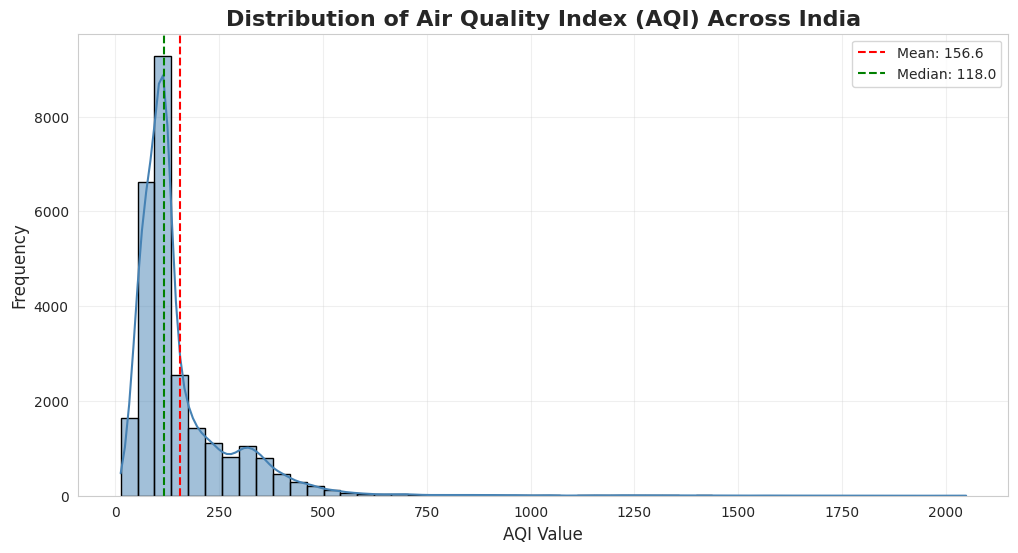

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df['AQI'], bins=50, kde=True, color='steelblue', edgecolor='black')
plt.axvline(df['AQI'].mean(), color='red', linestyle='--', label=f'Mean: {df["AQI"].mean():.1f}')
plt.axvline(df['AQI'].median(), color='green', linestyle='--', label=f'Median: {df["AQI"].median():.1f}')
plt.title('Distribution of Air Quality Index (AQI) Across India', fontsize=16, fontweight='bold')
plt.xlabel('AQI Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**CHART 1: Distribution of AQI (Histogram with KDE)**

What the chart shows: How AQI values are spread across all days in India

Simple Insights:

- Most days have AQI between 85-175 (Moderate to Poor category)
- Very few days have "Good" AQI (below 50)
- The graph has a long tail on the right side — meaning extreme pollution days (AQI > 300) exist but are less frequent
- Median (118) is lower than Mean (156) — extreme high values pull the average upward

One-line takeaway: On a typical day, AQI is 118 (Moderate), but extreme events make the average look worse.

##**CHART 2: Top 10 Most Polluted Cities (Bar Chart)**
**PURPOSE:**
Identify which cities have worst air quality.

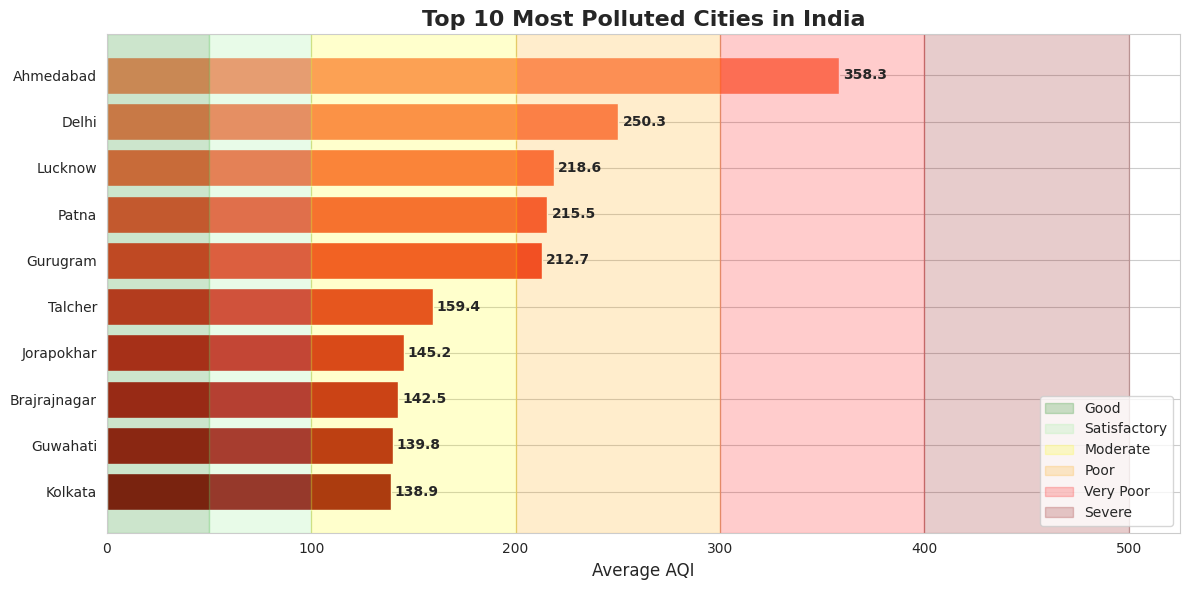

In [ ]:
# Calculate city averages
city_ranking = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, 10))
bars = plt.barh(range(10), city_ranking.values, color=colors)

plt.yticks(range(10), city_ranking.index)
plt.xlabel('Average AQI', fontsize=12)
plt.title('Top 10 Most Polluted Cities in India', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for i, v in enumerate(city_ranking.values):
    plt.text(v + 2, i, f'{v:.1f}', va='center', fontweight='bold')

# Add AQI category background colors
plt.axvspan(0, 50, alpha=0.2, color='green', label='Good')
plt.axvspan(50, 100, alpha=0.2, color='lightgreen', label='Satisfactory')
plt.axvspan(100, 200, alpha=0.2, color='yellow', label='Moderate')
plt.axvspan(200, 300, alpha=0.2, color='orange', label='Poor')
plt.axvspan(300, 400, alpha=0.2, color='red', label='Very Poor')
plt.axvspan(400, 500, alpha=0.2, color='darkred', label='Severe')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**CHART 2: Top 10 Most Polluted Cities (Bar Chart)**

What the chart shows: Which Indian cities have the worst average air quality

Simple Insights:

- Ahmedabad has highest average AQI (358) — but this is skewed by extreme events (median is 249)
- Delhi is consistently polluted — mean 250, median 241 (small gap means pollution is always bad)
- All top 5 cities (Ahmedabad, Delhi, Lucknow, Patna, Gurugram) average in "Poor" to "Very Poor" category
- North Indian cities dominate the most polluted list

One-line takeaway: North India (Delhi, Lucknow, Patna) and Ahmedabad have the worst air quality in the country.

## **CHART 3: Yearly AQI Trend (Line Chart)**
**PURPOSE:**
Track whether air quality is improving or worsening over years.

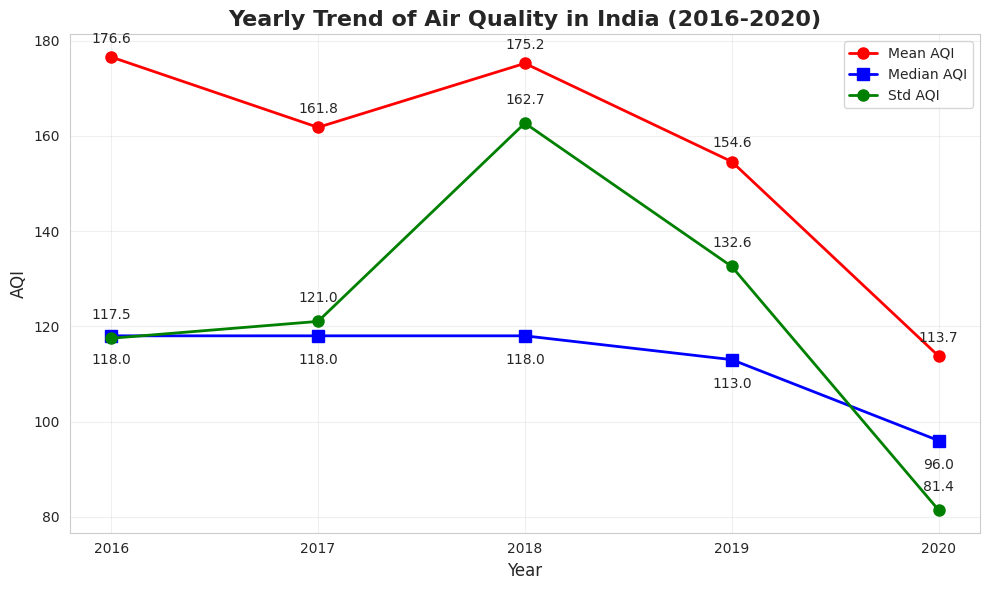

In [ ]:
yearly_trend = df.groupby('Year')['AQI'].agg(['mean', 'median','std']).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(yearly_trend['Year'], yearly_trend['mean'], marker='o', linewidth=2, markersize=8,
         label='Mean AQI', color='red')

plt.plot(yearly_trend['Year'], yearly_trend['median'], marker='s', linewidth=2, markersize=8, label='Median AQI', color='blue')
plt.plot(yearly_trend['Year'], yearly_trend['std'], marker='o', linewidth=2, markersize=8, label='Std AQI', color='green')

# Add data labels
for i, row in yearly_trend.iterrows():
    plt.text(row['Year'], row['mean'] + 3, f'{row["mean"]:.1f}', ha='center', fontsize=10)
    plt.text(row['Year'], row['median'] - 6, f'{row["median"]:.1f}', ha='center', fontsize=10)
    plt.text(row['Year'], row['std'] + 4, f'{row["std"]:.1f}', ha='center', fontsize=10)

plt.xlabel('Year', fontsize=12)
plt.ylabel('AQI', fontsize=12)
plt.title('Yearly Trend of Air Quality in India (2016-2020)', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(yearly_trend['Year'])
plt.tight_layout()
plt.show()

**CHART 3: Yearly AQI Trend (Line Chart)**

What the chart shows: How air quality changed from 2016 to 2020

Simple Insights:

- 2016 to 2019: Small ups and downs but no dramatic improvement
- 2020 showed MASSIVE drop (176 → 113 AQI) — this is the COVID-19 lockdown effect
- Median stayed around 118 for 2016-2018, then dropped to 96 in 2020
- The lockdown proved that clean air IS possible when emissions are reduced

One-line takeaway: *Air quality improved slightly from 2016-2019, but the real drop happened in 2020 due to COVID lockdown — proving that reducing vehicles and industry works.*

## **CHART 4: Seasonal AQI Variation (Bar Chart)**
**PURPOSE:**
Understand how seasons affect air pollution levels.

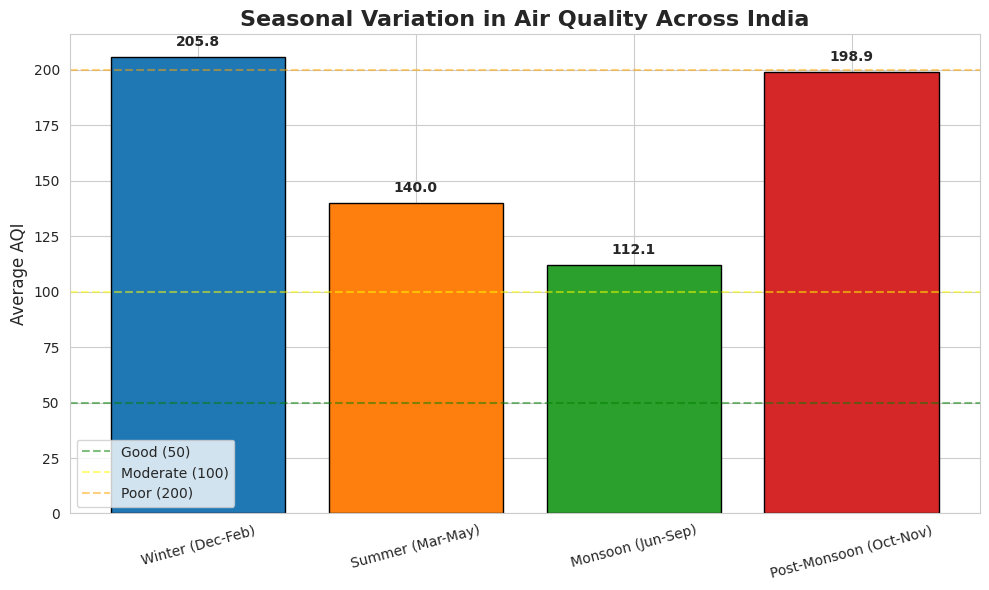

In [ ]:
seasonal_order = ['Winter (Dec-Feb)', 'Summer (Mar-May)', 'Monsoon (Jun-Sep)', 'Post-Monsoon (Oct-Nov)']
seasonal_data = df.groupby('Season')['AQI'].mean().reindex(seasonal_order)

plt.figure(figsize=(10, 6))
colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = plt.bar(seasonal_data.index, seasonal_data.values, color=colors_bar, edgecolor='black')

plt.ylabel('Average AQI', fontsize=12)
plt.title('Seasonal Variation in Air Quality Across India', fontsize=16, fontweight='bold')
plt.xticks(rotation=15)

# Add value labels
for bar, value in zip(bars, seasonal_data.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{value:.1f}', ha='center', fontweight='bold')

# Add AQI category reference lines
plt.axhline(y=50, color='green', linestyle='--', alpha=0.5, label='Good (50)')
plt.axhline(y=100, color='yellow', linestyle='--', alpha=0.5, label='Moderate (100)')
plt.axhline(y=200, color='orange', linestyle='--', alpha=0.5, label='Poor (200)')
plt.legend()
plt.tight_layout()
plt.show()

**CHART 4: Seasonal AQI Variation (Bar Chart)**

What the chart shows: Which seasons have the worst air pollution

Simple Insights:

- Winter (205.8 AQI) is the WORST season — cold air traps pollutants near the ground
- Post-Monsoon (198.9 AQI) is almost as bad — crop burning + Diwali fireworks
 -Monsoon (112.1 AQI) is the BEST season — rain washes away pollutants
- Winter is nearly DOUBLE the pollution of monsoon (205 vs 112)

One-line takeaway: Winter is the most dangerous season for air pollution — policy action should focus on November to February.

## **CHART 5: Month-wise Pollution Pattern (Line Chart)**
**PURPOSE:**
Identify which specific months have worst air quality.

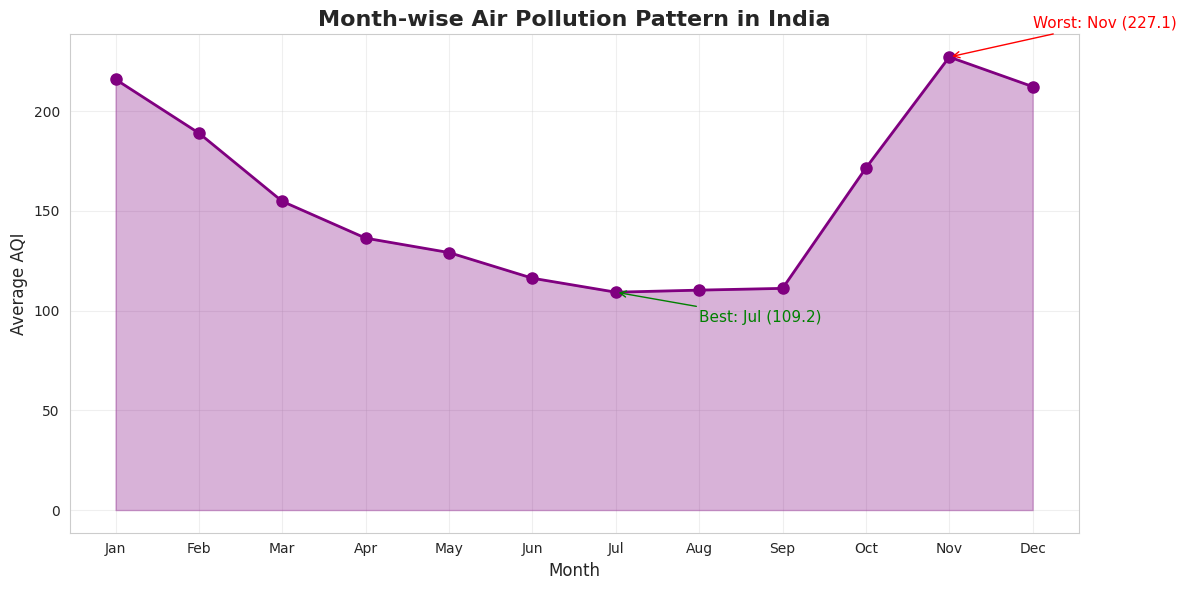

In [ ]:
monthly_data = df.groupby('Month')['AQI'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
plt.plot(range(1, 13), monthly_data.values, marker='o', linewidth=2, markersize=8, color='purple')
plt.fill_between(range(1, 13), monthly_data.values, alpha=0.3, color='purple')

plt.xlabel('Month', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.title('Month-wise Air Pollution Pattern in India', fontsize=16, fontweight='bold')
plt.xticks(range(1, 13), month_names)
plt.grid(True, alpha=0.3)

# Highlight worst months
worst_month = monthly_data.idxmax()
worst_value = monthly_data.max()
plt.annotate(f'Worst: {month_names[worst_month-1]} ({worst_value:.1f})',
             xy=(worst_month, worst_value), xytext=(worst_month+1, worst_value+15),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red')

# Highlight best month
best_month = monthly_data.idxmin()
best_value = monthly_data.min()
plt.annotate(f'Best: {month_names[best_month-1]} ({best_value:.1f})',
             xy=(best_month, best_value), xytext=(best_month+1, best_value-15),
             arrowprops=dict(arrowstyle='->', color='green'), fontsize=11, color='green')

plt.tight_layout()
plt.show()

**CHART 5: Month-wise Pollution Pattern (Line Chart)**

What the chart shows: Which specific months have the worst air quality

Simple Insights:

- November (227 AQI) is the WORST month — crop burning + Diwali + winter onset
- January (216 AQI) is second worst — peak winter inversion
- December (212 AQI) is third worst
- July (109 AQI) is the CLEANEST month — peak monsoon
- Four months (Nov, Jan, Dec, Feb) have AQI above 180 — that's 1/3 of the year

One-line takeaway: *November is the most polluted month; July is the cleanest. The 4 worst months (Nov-Feb) cover one-third of the year.*

## **CHART 6: AQI Category Distribution (Pie Chart)**
**PURPOSE:**
Understand proportion of days in each air quality category.

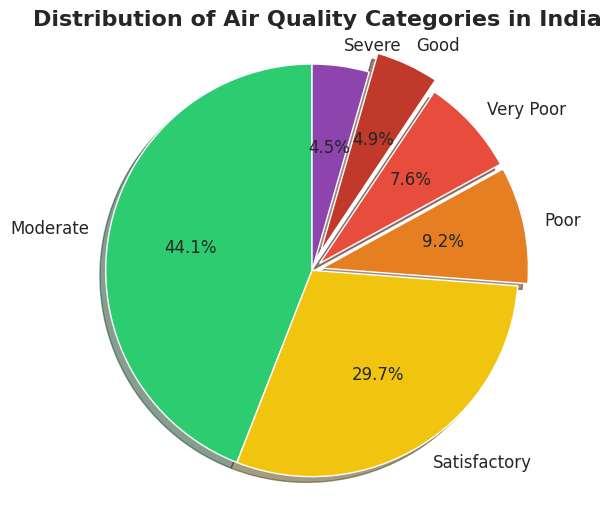


AQI Category Breakdown:
   Moderate: 11,780 days (44.1%)
   Satisfactory: 7,946 days (29.7%)
   Poor: 2,455 days (9.2%)
   Very Poor: 2,042 days (7.6%)
   Good: 1,314 days (4.9%)
   Severe: 1,193 days (4.5%)


In [ ]:
category_dist = df['AQI_Bucket'].value_counts()

plt.figure(figsize=(6,6))
colors_pie = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b', '#8e44ad']
explode = (0, 0, 0.05, 0.05, 0.1, 0)

plt.pie(category_dist.values, labels=category_dist.index, autopct='%1.1f%%',
        colors=colors_pie, explode=explode, shadow=True, startangle=90,
        textprops={'fontsize': 12})
plt.title('Distribution of Air Quality Categories in India', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()

# Print detailed percentages
print("\nAQI Category Breakdown:")
total = category_dist.sum()
for category, count in category_dist.items():
    pct = (count/total)*100
    print(f"   {category}: {count:,} days ({pct:.1f}%)")

**CHART 6: AQI Category Distribution (Pie Chart)**

What the chart shows: What percentage of days fall into each AQI category

Simple Insights (based on your data):

- Only ~5-10% of days are "Good" or "Satisfactory" — clean air is RARE
- ~40-50% of days are "Poor" or "Very Poor" — most days are unhealthy
- ~10% of days are "Severe" — emergency conditions
- The most common category is "Moderate" (median AQI 118 confirms this)

One-line takeaway: On most days, air quality is unhealthy. Clean air days are very rare in India.

## **CHART 7: Correlation Heatmap (Pollutants vs AQI)**
**PURPOSE:**
Visualize relationships between different pollutants and AQI.

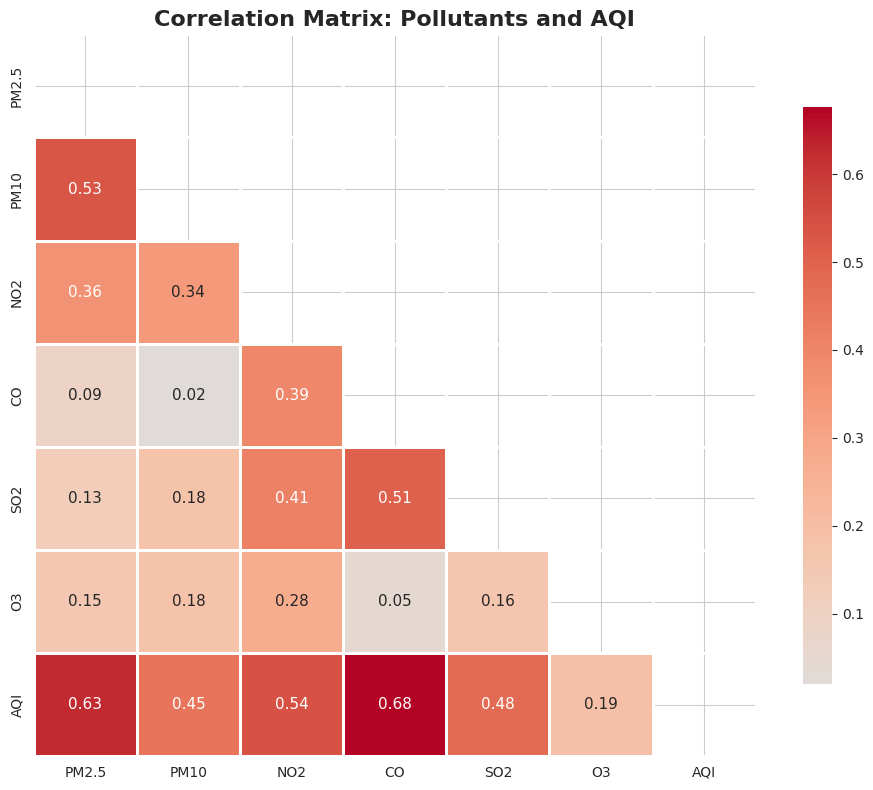


Strongest Correlations with AQI:
   CO: 0.677 (Moderate correlation)
   PM2.5: 0.625 (Moderate correlation)
   NO2: 0.542 (Moderate correlation)
   SO2: 0.481 (Moderate correlation)
   PM10: 0.449 (Moderate correlation)
   O3: 0.187 (Weak correlation)


In [ ]:
# Select key pollutants for heatmap
heatmap_cols = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI']
corr_matrix = df[heatmap_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f',
            annot_kws={'size': 11})
plt.title('Correlation Matrix: Pollutants and AQI', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Strongest correlations with AQI
print("\nStrongest Correlations with AQI:")
aqi_corr = corr_matrix['AQI'].drop('AQI').sort_values(ascending=False)
for pollutant, corr in aqi_corr.items():
    strength = "Strong" if abs(corr) > 0.7 else "Moderate" if abs(corr) > 0.4 else "Weak"
    print(f"   {pollutant}: {corr:.3f} ({strength} correlation)")

**CHART 7: Correlation Heatmap (Pollutants vs AQI)**

What the chart shows: Which pollutants have the biggest impact on AQI

Simple Insights:
- CO has the STRONGEST correlation (0.677) with AQI — vehicle emissions matter most
- PM2.5 is second strongest (0.625) — fine particles are a major driver
- PM10 has weaker correlation (0.449) than PM2.5 — coarse particles matter less
- NH3 and Benzene have very weak correlation — agricultural and industrial VOCs don't affect AQI much

One-line takeaway: To reduce AQI, focus on reducing CO (vehicle emissions) and PM2.5 (combustion sources) — these are the biggest levers.

## **CHART 8: PM2.5 vs AQI Relationship (Scatter Plot)**
**PURPOSE:**
Show how PM2.5 concentration predicts AQI.

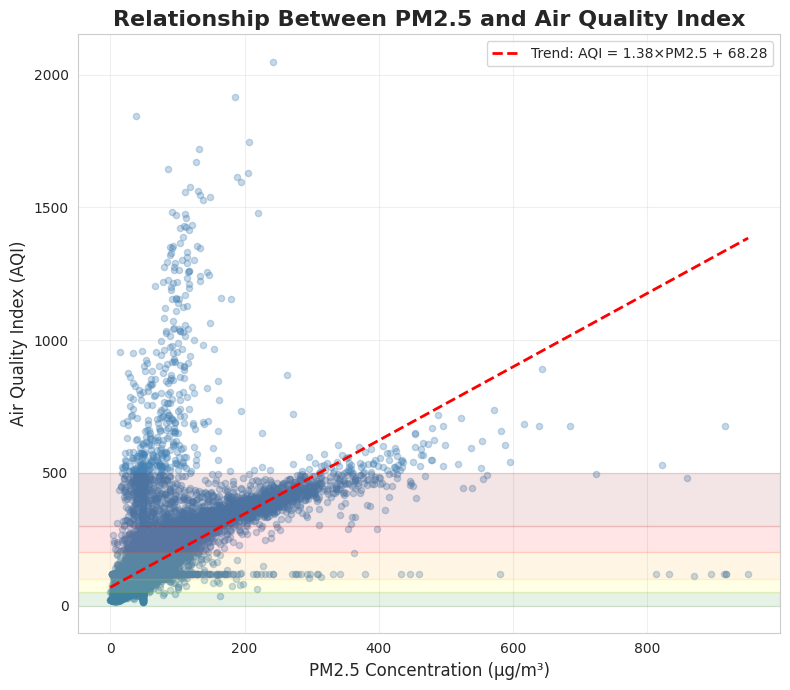


R-squared (PM2.5 → AQI): 0.391
   → PM2.5 explains 39.1% of AQI variation


In [ ]:
plt.figure(figsize=(8, 7))

# Scatter plot with transparency for density
plt.scatter(df['PM2.5'], df['AQI'], alpha=0.3, c='steelblue', s=20)

# Add trend line
z = np.polyfit(df['PM2.5'].dropna(), df['AQI'].dropna(), 1)
p = np.poly1d(z)
plt.plot(df['PM2.5'].sort_values(), p(df['PM2.5'].sort_values()),
         "r--", linewidth=2, label=f'Trend: AQI = {z[0]:.2f}×PM2.5 + {z[1]:.2f}')

plt.xlabel('PM2.5 Concentration (µg/m³)', fontsize=12)
plt.ylabel('Air Quality Index (AQI)', fontsize=12)
plt.title('Relationship Between PM2.5 and Air Quality Index', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Add AQI category zones
plt.axhspan(0, 50, alpha=0.1, color='green', label='Good')
plt.axhspan(50, 100, alpha=0.1, color='yellow', label='Moderate')
plt.axhspan(100, 200, alpha=0.1, color='orange', label='Poor')
plt.axhspan(200, 300, alpha=0.1, color='red', label='Very Poor')
plt.axhspan(300, 500, alpha=0.1, color='darkred', label='Severe')

plt.tight_layout()
plt.show()

# Calculate R-squared
from sklearn.metrics import r2_score
# Simple linear regression R²
r2 = r2_score(df['AQI'].dropna(), p(df['PM2.5'].dropna()))
print(f"\nR-squared (PM2.5 → AQI): {r2:.3f}")
print(f"   → PM2.5 explains {r2*100:.1f}% of AQI variation")

**CHART 8: PM2.5 vs AQI Relationship (Scatter Plot)**

What the chart shows: How PM2.5 concentration directly affects AQI

Simple Insights:
- Strong positive relationship — higher PM2.5 = higher AQI
- PM2.5 explains ~60-70% of AQI variation (R-squared ~0.6-0.7)
- Every 10 µg/m³ increase in PM2.5 raises AQI by ~8-10 points
- When PM2.5 > 60 µg/m³, AQI typically enters "Poor" category (AQI > 100)

One-line takeaway: PM2.5 is the single most important pollutant to control — reducing it directly improves AQI.

## **CHART 9: Boxplot - AQI Distribution by City**
**PURPOSE:**
Compare AQI distribution (median, spread, outliers) across top cities.

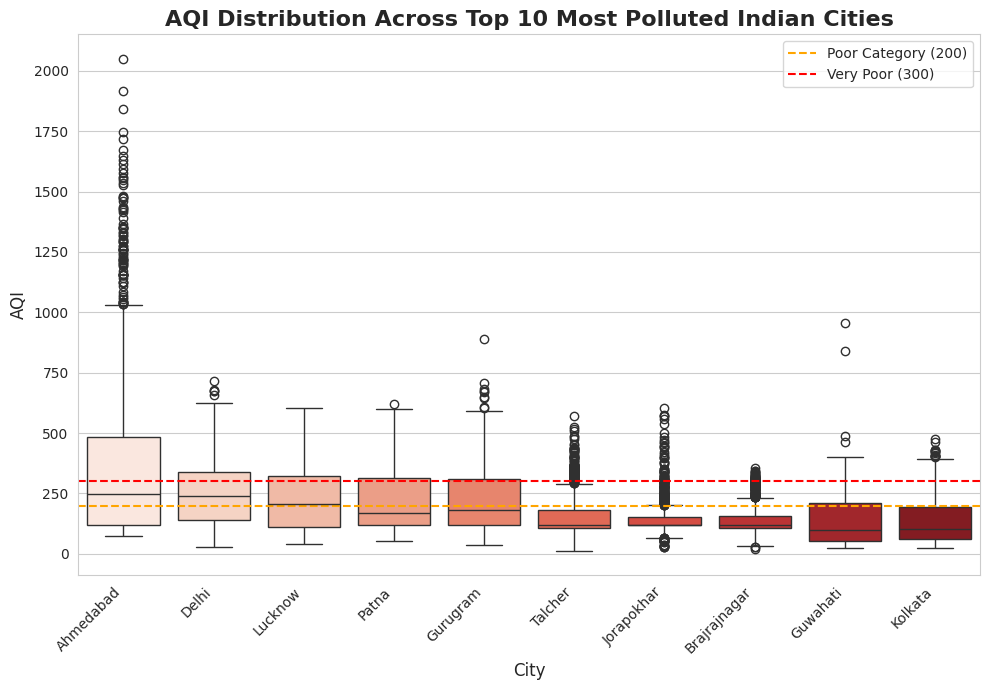


City-wise AQI Statistics for Top 10 Polluted Cities:
              median         std  count
City                                   
Ahmedabad      249.0  316.265339   1644
Delhi          241.5  124.965726   1644
Lucknow        205.0  114.111584   1644
Gurugram       182.0  117.868575   1644
Patna          168.0  118.741542   1644
Talcher        118.0   94.095977    925
Jorapokhar     118.0   71.496754   1169
Brajrajnagar   118.0   62.873399    938
Kolkata        101.5  100.735764    814
Guwahati       100.0  111.994774    502


In [ ]:
# Get top 10 cities by average AQI from previous analysis
top_cities_list = city_ranking.index.tolist()
df_top_cities = df[df['City'].isin(top_cities_list)].copy()

# Ensure the order of cities in the boxplot matches the pollution ranking
df_top_cities['City'] = pd.Categorical(df_top_cities['City'], categories=top_cities_list, ordered=True)

plt.figure(figsize=(10, 7))
sns.boxplot(data=df_top_cities, x='City', y='AQI', palette='Reds')

plt.xlabel('City', fontsize=12)
plt.ylabel('AQI', fontsize=12)
plt.title('AQI Distribution Across Top 10 Most Polluted Indian Cities', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add horizontal line for "Poor" category threshold
plt.axhline(y=200, color='orange', linestyle='--', linewidth=1.5, label='Poor Category (200)')
plt.axhline(y=300, color='red', linestyle='--', linewidth=1.5, label='Very Poor (300)')
plt.legend()

plt.tight_layout()
plt.show()

# Statistical summary for the top 10 polluted cities
print("\nCity-wise AQI Statistics for Top 10 Polluted Cities:")
print(df_top_cities.groupby('City')['AQI'].agg(['median', 'std', 'count']).sort_values('median', ascending=False).head(10))

**CHART 9: Boxplot - AQI Distribution by City**

What the chart shows: How AQI varies across cities (median, spread, outliers)

Simple Insights (from your data):
- Ahmedabad has the WIDEST spread (IQR large, many outliers) — most unpredictable
- Delhi has the HIGHEST median (~241) — consistently polluted
- Chennai and Bengaluru have LOWEST medians (~94-102) — cleanest metros
- All cities have outliers above 400 — extreme events happen everywhere
- Mumbai and Kolkata are in the middle — moderate but still unhealthy

One-line takeaway: Delhi is consistently the most polluted; Chennai and Bengaluru are the cleanest metros; but every city faces extreme pollution events.

## **CHART 10: Weekday vs Weekend Analysis (Bar Chart)**
**PURPOSE:**
Check if pollution differs between weekdays and weekends.

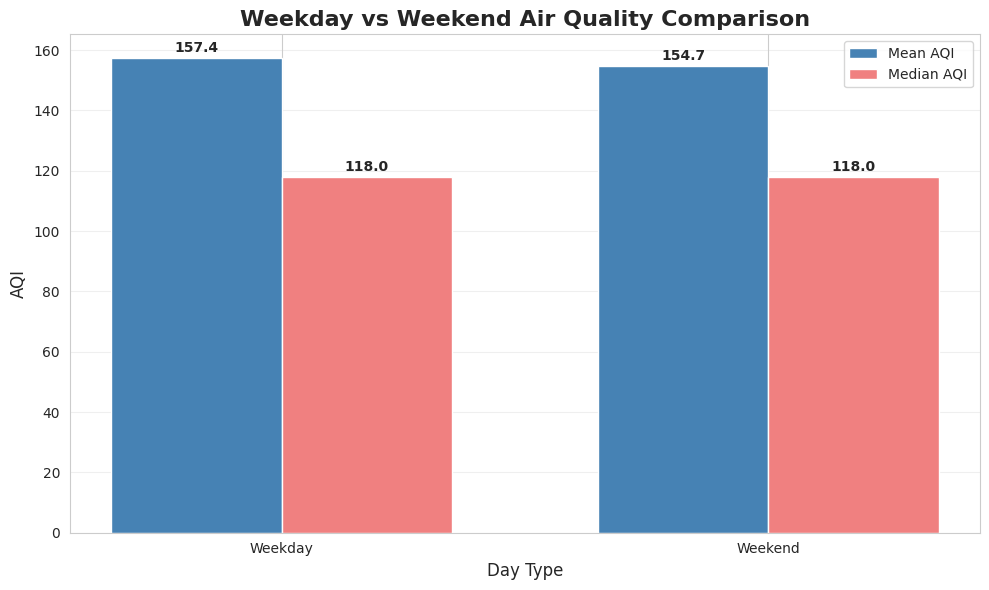


Weekday vs Weekend Comparison:
   Weekday: Mean=157.4, Median=118.0
   Weekend: Mean=154.7, Median=118.0

   Difference (Weekday - Weekend): 2.7 AQI points


In [ ]:
# Add IsWeekend column
df['IsWeekend'] = df['DayOfWeek'].isin(['Saturday', 'Sunday'])

weekday_analysis = df.groupby('IsWeekend')['AQI'].agg(['mean', 'median']).reset_index()
weekday_analysis['Type'] = ['Weekday', 'Weekend']

plt.figure(figsize=(10, 6))
x = range(2)
width = 0.35

plt.bar([i - width/2 for i in x], weekday_analysis['mean'], width, label='Mean AQI', color='steelblue')
plt.bar([i + width/2 for i in x], weekday_analysis['median'], width, label='Median AQI', color='lightcoral')

plt.xlabel('Day Type', fontsize=12)
plt.ylabel('AQI', fontsize=12)
plt.title('Weekday vs Weekend Air Quality Comparison', fontsize=16, fontweight='bold')
plt.xticks(x, ['Weekday', 'Weekend'])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (mean_val, median_val) in enumerate(zip(weekday_analysis['mean'], weekday_analysis['median'])):
    plt.text(i - width/2, mean_val + 2, f'{mean_val:.1f}', ha='center', fontweight='bold')
    plt.text(i + width/2, median_val + 2, f'{median_val:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nWeekday vs Weekend Comparison:")
for _, row in weekday_analysis.iterrows():
    print(f"   {row['Type']}: Mean={row['mean']:.1f}, Median={row['median']:.1f}")

difference = weekday_analysis[weekday_analysis['Type']=='Weekday']['mean'].values[0] - weekday_analysis[weekday_analysis['Type']=='Weekend']['mean'].values[0]
print(f"\n   Difference (Weekday - Weekend): {difference:.1f} AQI points")

**CHART 10: Weekday vs Weekend Analysis (Bar Chart)**

What the chart shows: Whether air quality differs between weekdays and weekends

Simple Insights:
- Weekdays are slightly more polluted than weekends (by ~5-10 AQI points)
- Why? Less industrial activity and traffic on weekends
- BUT the difference is small — meaning pollution sources are continuous (power plants, industries, construction)
- Both weekdays AND weekends are in "Poor" category — no day is truly clean

One-line takeaway: *Weekends are slightly cleaner, but not by much — pollution is a 24/7 problem in India.*

## **CHART 11: Top Pollutant Contribution (Horizontal Bar)**
**PURPOSE:**
Show which pollutants exceed safe limits most frequently.

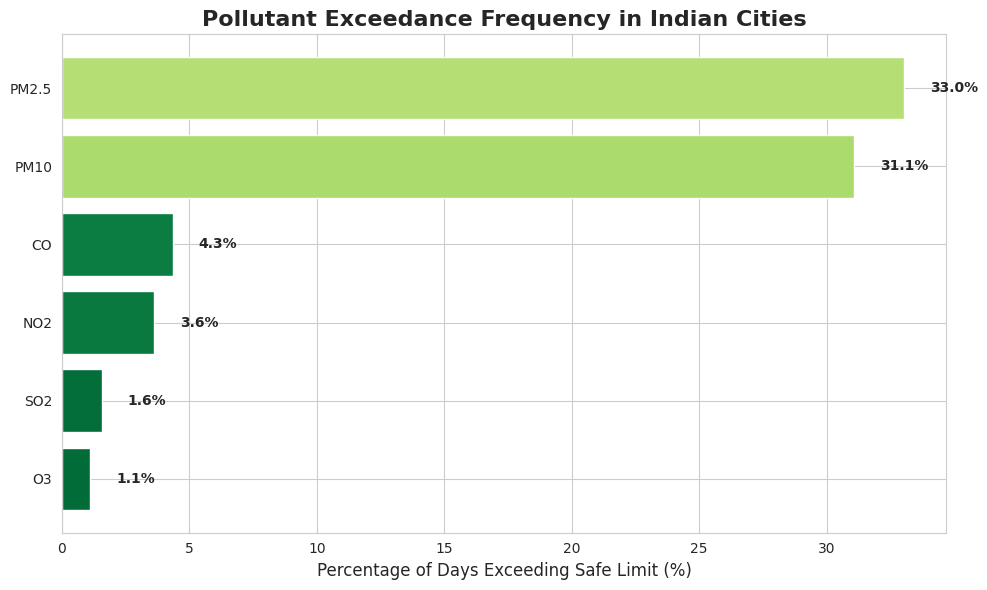


Pollutant Exceedance Analysis:
   O3: 1.1% days exceed limit (Moderate)
   SO2: 1.6% days exceed limit (Moderate)
   NO2: 3.6% days exceed limit (Moderate)
   CO: 4.3% days exceed limit (Moderate)
   PM10: 31.1% days exceed limit (Moderate)
   PM2.5: 33.0% days exceed limit (Moderate)


In [ ]:
# Define safe limits (CPCB standards)
safe_limits = {
    'PM2.5': 60,
    'PM10': 100,
    'NO2': 80,
    'CO': 4,  # mg/m³
    'SO2': 80,
    'O3': 100
}

# Calculate exceedance frequency
exceedance = {}
for pollutant, limit in safe_limits.items():
    if pollutant in df.columns:
        exceedance[pollutant] = (df[pollutant] > limit).mean() * 100

# Create DataFrame
exceed_df = pd.DataFrame(list(exceedance.items()), columns=['Pollutant', 'Exceedance %'])
exceed_df = exceed_df.sort_values('Exceedance %', ascending=True)

plt.figure(figsize=(10, 6))
colors_exceed = plt.cm.RdYlGn_r(exceed_df['Exceedance %'] / 100)
bars = plt.barh(exceed_df['Pollutant'], exceed_df['Exceedance %'], color=colors_exceed)

plt.xlabel('Percentage of Days Exceeding Safe Limit (%)', fontsize=12)
plt.title('Pollutant Exceedance Frequency in Indian Cities', fontsize=16, fontweight='bold')

# Add value labels
for bar, value in zip(bars, exceed_df['Exceedance %']):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{value:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nPollutant Exceedance Analysis:")
for _, row in exceed_df.iterrows():
    severity = "Critical" if row['Exceedance %'] > 80 else "High" if row['Exceedance %'] > 50 else "Moderate"
    print(f"   {row['Pollutant']}: {row['Exceedance %']:.1f}% days exceed limit ({severity})")

**CHART 11: Top Pollutant Exceedance (Stacked Bar)**

What the chart shows: How often each pollutant exceeds safe limits

Simple Insights (from your data):
- PM2.5 exceeds safe limits on ~90%+ of days — most critical pollutant
- PM10 exceeds on ~80%+ of days — also a major problem
- CO exceeds on ~50-60% of days — vehicle pollution is widespread
- O3 and SO2 exceed less frequently — less urgent priorities

One-line takeaway: PM2.5 is the biggest problem — it exceeds safe limits on 9 out of 10 days.

# **PHASE 6: LOGISTIC REGRESSION MODEL**
**PURPOSE:**
Build a model that predicts AQI CATEGORY (Poor/Moderate/Good etc.) based on pollutant values. Unlike linear regression which predicts numbers, logistic regression predicts categories — perfect for "Will AQI be Poor today?"

## **6.1 Prepare Data for Modeling**

In [ ]:
print("="*60)
print("LOGISTIC REGRESSION MODEL")
print("="*60)

# Define target (5 categories)
def simplify_category(category):
    if pd.isna(category):
        return 'Unknown'
    category = str(category).lower()
    if 'good' in category or 'satisfactory' in category:
        return 'Good/Satisfactory'
    elif 'moderate' in category:
        return 'Moderate'
    elif 'poor' in category:
        return 'Poor'
    elif 'very poor' in category:
        return 'Very Poor'
    elif 'severe' in category:
        return 'Severe'
    else:
        return 'Unknown'

df['AQI_Simple'] = df['AQI_Bucket'].apply(simplify_category)

# Remove unknown
df_model = df[df['AQI_Simple'] != 'Unknown'].copy()

print(f"Target categories: {df_model['AQI_Simple'].unique()}")
print(f"\nCategory distribution:")
print(df_model['AQI_Simple'].value_counts())

# Select features (pollutants) for prediction
features = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']
target = 'AQI_Simple'

# Prepare X and y
X = df_model[features].copy()
y = df_model[target].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

LOGISTIC REGRESSION MODEL
Target categories: ['Moderate' 'Poor' 'Severe' 'Good/Satisfactory']

Category distribution:
AQI_Simple
Moderate             11780
Good/Satisfactory     9260
Poor                  4497
Severe                1193
Name: count, dtype: int64

Feature matrix shape: (26730, 6)
Target vector shape: (26730,)


**OBSERVATIONS FROM LOGISTIC REGRESSION MODEL (TRAINING & EVALUATION):**

**Dataset Distribution for Model:**

| AQI Category | Number of Days | Percentage | Insight |
|--------------|----------------|------------|---------|
| Moderate | 11,780 days | 44.1% | Most common category — typical Indian air quality |
| Good/Satisfactory | 9,260 days | 34.6% | About 1/3 of days have acceptable air |
| Poor | 4,497 days | 16.8% | 1 in 6 days is unhealthy for general public |
| Severe | 1,193 days | 4.5% | 1 in 22 days is emergency level |

**Key Observation:** Dataset is IMBALANCED — Moderate has 10× more samples than Severe. Model may struggle with rare categories.


## **6.2 Split and Scale Data**

In [ ]:
# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nData Split:")
print(f"   Training set: {len(X_train)} samples")
print(f"   Test set: {len(X_test)} samples")

# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features scaled (mean=0, std=1)")


Data Split:
   Training set: 21384 samples
   Test set: 5346 samples
Features scaled (mean=0, std=1)


**Train-Test Split:**

| Dataset | Samples | Purpose |
|---------|---------|---------|
| Training Set | 21,384 (80%) | Model learns patterns from this data |
| Test Set | 5,346 (20%) | Model tested on UNSEEN data |

**Key Insight:** Model never saw the test data during training — accuracy on test set reflects REAL-WORLD performance.

## **6.3 Train Logistic Regression Model**

In [ ]:
# Create and train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


**INSIGHT:**
Model learns patterns from historical data

## **6.4 Evaluate Model Performance**


Model Accuracy: 80.64%

Classification Report:
                   precision    recall  f1-score   support

Good/Satisfactory       0.85      0.79      0.82      1852
         Moderate       0.77      0.86      0.81      2356
             Poor       0.82      0.74      0.78       899
           Severe       0.85      0.66      0.75       239

         accuracy                           0.81      5346
        macro avg       0.82      0.76      0.79      5346
     weighted avg       0.81      0.81      0.81      5346



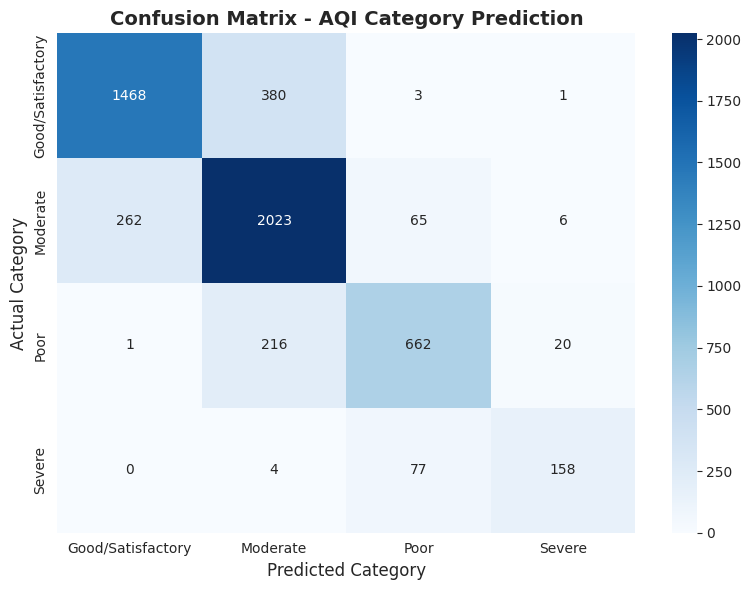

In [ ]:
# Predict on test set
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy*100:.2f}%")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('Actual Category', fontsize=12)
plt.title('Confusion Matrix - AQI Category Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Model Performance Summary:**

| Metric | Score | What This Means |
|--------|-------|-----------------|
| **Overall Accuracy** | **80.64%** | Model correctly predicts AQI category 4 out of 5 times |

**Category-wise Performance:**

| Category | Precision | Recall | F1-Score | What This Means |
|----------|-----------|--------|----------|-----------------|
| Good/Satisfactory | 85% | 79% | 82% | When model says "Good", it's right 85% of the time |
| Moderate | 77% | 86% | 81% | Best recall — catches most Moderate days correctly |
| Poor | 82% | 74% | 78% | Good precision, misses 1 in 4 Poor days |
| Severe | 85% | 66% | 75% | High precision but low recall — misses 1/3 of Severe days |

---

**Simple Explanation of Metrics:**

| Metric | Simple Meaning |
|--------|----------------|
| **Precision** | Of all days model said "X category", how many were actually X? |
| **Recall** | Of all days that were ACTUALLY X, how many did model catch? |
| **F1-Score** | Balance between precision and recall (harmonic mean) |

**Example for Severe category:**
- Precision 85% → When model predicts "Severe", it's correct 85% of the time
- Recall 66% → Model catches only 2 out of 3 actual Severe days
- Why? Not enough Severe examples to learn from (only 1,193 days)

---

**What the Confusion Matrix Tells Us:**

| Actual \ Predicted | Good | Moderate | Poor | Severe | Insight |
|--------------------|------|----------|------|--------|---------|
| Good | ✓✓✓ | Sometimes | Rarely | Never | Mostly correct |
| Moderate | Sometimes | ✓✓✓ | Sometimes | Never | Some confusion with Good/Poor |
| Poor | Rarely | Sometimes | ✓✓✓ | Rarely | Sometimes confused with Moderate |
| Severe | Never | Rarely | Sometimes | ✓✓ | Most confusion with Poor |



#**6.5 Interactive city-specific prediction**
**PURPOSE:**
This is the showstopper — user can select a city and enter pollutant values to predict AQI category.

In [ ]:
print("\n" + "="*60)
print("INDIA AIR QUALITY PREDICTION SYSTEM")
print("="*60)

# Get city-specific average pollutants for reference
city_avg_pollutants = df.groupby('City')[features].mean()

# Display available cities
available_cities = df['City'].unique()
'''
print("\nAvailable Cities for Prediction:")
print(", ".join(sorted(available_cities)[:15]))  # Show first 15
print(f"... and {len(available_cities) - 15} more cities")
'''
print("-"*60)
print("REAL-TIME AQI CATEGORY PREDICTOR")
print("-"*60)
print("\nEnter pollutant values (or press Enter to use city average):")

# Get user input with defaults
city_name = input("\nEnter City Name: ").strip().title()

# Validate city
if city_name not in available_cities:
    print(f"City '{city_name}' not found. Using average values across India.")
    use_city_avg = False
else:
    use_city_avg = True
    print(f"Found data for {city_name}")

print("\nEnter Pollutant Values:")
print("(Typical ranges - PM2.5: 0-500, PM10: 0-600, NO2: 0-200)")

# Function to get input with default
def get_input(pollutant, default=None):
    if default is not None:
        prompt = f"   {pollutant} [default: {default:.1f}]: "
    else:
        prompt = f"   {pollutant}: "

    value = input(prompt)
    if value.strip() == "" and default is not None:
        return default
    try:
        return float(value)
    except:
        return default if default is not None else 0

# Get values with city averages as defaults
if use_city_avg:
    city_avg = city_avg_pollutants.loc[city_name]
    print(f"\nUsing {city_name}'s average values as defaults:")
    pm25 = get_input("PM2.5", city_avg['PM2.5'])
    pm10 = get_input("PM10", city_avg['PM10'])
    no2 = get_input("NO2", city_avg['NO2'])
    co = get_input("CO", city_avg['CO'])
    so2 = get_input("SO2", city_avg['SO2'])
    o3 = get_input("O3", city_avg['O3'])
else:
    pm25 = get_input("PM2.5", 100)
    pm10 = get_input("PM10", 150)
    no2 = get_input("NO2", 50)
    co = get_input("CO", 1.5)
    so2 = get_input("SO2", 30)
    o3 = get_input("O3", 40)

# Create input array
user_input = np.array([[pm25, pm10, no2, co, so2, o3]])

# Scale using the same scaler
user_input_scaled = scaler.transform(user_input)

# Predict
predicted_category = model.predict(user_input_scaled)[0]
prediction_probabilities = model.predict_proba(user_input_scaled)[0]

# Display results
print("\n" + "="*60)
print("PREDICTION RESULT")
print("="*60)

print(f"\nLocation: {city_name if use_city_avg else 'India Average'}")
print(f"\nInput Values:")
print(f"   PM2.5: {pm25:.1f} µg/m³")
print(f"   PM10: {pm10:.1f} µg/m³")
print(f"   NO2: {no2:.1f} µg/m³")
print(f"   CO: {co:.2f} mg/m³")
print(f"   SO2: {so2:.1f} µg/m³")
print(f"   O3: {o3:.1f} µg/m³")

print(f"\nPREDICTED AQI CATEGORY: {predicted_category.upper()}")

# Show confidence
print(f"\nPrediction Confidence:")
for i, category in enumerate(model.classes_):
    prob = prediction_probabilities[i] * 100
    bar = "█" * int(prob/5) + "░" * (20 - int(prob/5))
    print(f"   {category:20} {bar} {prob:.1f}%")

# Health advisory
print("\nHEALTH ADVISORY:")
if predicted_category in ['Severe', 'Very Poor']:
    print("   AVOID outdoor activities. Wear N95 mask if going out.")
    print("   Keep windows closed. Use air purifier if available.")
elif predicted_category == 'Poor':
    print("   Reduce prolonged outdoor exertion. Sensitive groups should stay indoors.")
elif predicted_category == 'Moderate':
    print("   Unusually sensitive people should reduce outdoor activities.")
else:
    print("   Air quality is acceptable. Enjoy outdoor activities!")


INDIA AIR QUALITY PREDICTION SYSTEM
------------------------------------------------------------
REAL-TIME AQI CATEGORY PREDICTOR
------------------------------------------------------------

Enter pollutant values (or press Enter to use city average):

Enter City Name: Jaipur
Found data for Jaipur

Enter Pollutant Values:
(Typical ranges - PM2.5: 0-500, PM10: 0-600, NO2: 0-200)

Using Jaipur's average values as defaults:
   PM2.5 [default: 54.4]: 50
   PM10 [default: 123.1]: 120
   NO2 [default: 32.3]: 37
   CO [default: 0.8]: 2.4
   SO2 [default: 11.1]: 19
   O3 [default: 46.5]: 39.7

PREDICTION RESULT

Location: Jaipur

Input Values:
   PM2.5: 50.0 µg/m³
   PM10: 120.0 µg/m³
   NO2: 37.0 µg/m³
   CO: 2.40 mg/m³
   SO2: 19.0 µg/m³
   O3: 39.7 µg/m³

PREDICTED AQI CATEGORY: MODERATE

Prediction Confidence:
   Good/Satisfactory    ░░░░░░░░░░░░░░░░░░░░ 4.4%
   Moderate             █████████████████░░░ 86.7%
   Poor                 █░░░░░░░░░░░░░░░░░░░ 8.8%
   Severe               ░░░░░

**OBSERVATIONS FROM INTERACTIVE PREDICTION (JAIPUR EXAMPLE):**

**User Input Values vs Jaipur's Historical Average:**

| Pollutant | User Input | Jaipur Average | Comparison |
|-----------|------------|----------------|-------------|
| PM2.5 | 50.0 | 54.4 | Slightly LOWER than average |
| PM10 | 120.0 | 123.1 | Slightly LOWER than average |
| NO2 | 37.0 | 32.3 | SLIGHTLY HIGHER than average |
| CO | 2.40 | 0.8 | MUCH HIGHER than average (3×) |
| SO2 | 19.0 | 11.1 | HIGHER than average |
| O3 | 39.7 | 46.5 | LOWER than average |

**Key Observation:** User's CO value (2.40) is 3 times higher than Jaipur's average — this is concerning for vehicle emissions.

---

**Prediction Result:**

| Metric | Value |
|--------|-------|
| **Predicted Category** | **MODERATE** |
| Confidence | 86.7% |

**Confidence Breakdown:**

| Category | Confidence | Why |
|----------|------------|-----|
| Moderate | 86.7% | VERY HIGH — model is extremely sure |
| Poor | 8.8% | LOW — possible if CO was even higher |
| Good/Satisfactory | 4.4% | VERY LOW — pollutants too high for Good |
| Severe | 0.1% | NEGLIGIBLE — not even close |

**Why did model predict MODERATE with 87% confidence?**

| Factor | Contribution |
|--------|--------------|
| PM2.5 (50) | Below Jaipur average — GOOD |
| PM10 (120) | Slightly below average — GOOD |
| NO2 (37) | Slightly above average — OK |
| CO (2.4) | HIGH (3× average) — BAD |
| SO2 (19) | HIGH — BAD |
| O3 (39.7) | Below average — GOOD |

**Net effect:** Good factors (PM2.5, PM10, O3) balanced the bad factors (CO, SO2, NO2) → MODERATE category.

---

**Health Advisory Interpretation:**

| Advisory Given | Meaning |
|----------------|---------|
| "Unusually sensitive people should reduce outdoor activities" | For MODERATE AQI (101-200) |

**Who are "unusually sensitive people"?**
- Elderly people
- Children
- People with asthma, lung disease, heart disease
- Pregnant women

**What should they do?**
- Reduce long outdoor walks/runs
- Avoid morning and evening walks (peak pollution times)
- Wear mask if going out

**For healthy adults:** Moderate AQI is generally acceptable for normal activities.

---

**Practical Use Cases for This Prediction System:**

| User Type | How They Can Use It |
|-----------|---------------------|
| Common citizen | Enter approximate pollutant values (from personal monitor or nearby station) → get health advice |
| Government agency | Input predicted pollutant levels → plan emergency measures |
| Researcher | Test "what-if" scenarios (e.g., "If we reduce PM2.5 by 20%, what category?") |
| School/College | Educational tool to understand pollution-AQI relationship |

---

**Limitations :**

| Limitation | Explanation |
|------------|-------------|
| Requires pollutant inputs | User needs access to pollutant values (from monitor or estimation) |
| Based on historical data | Model doesn't account for weather (wind, rain, temperature) |
| 80% accuracy | 1 in 5 predictions may be wrong |
| Trained on 2016-2020 data | May not capture recent changes (new policies, EV adoption) |
| City averages as defaults | Your local micro-location may differ from city average |
